# 第三章探索性数据分析（EDA）

本 notebook 用于支撑论文第 3.3 节，先完成 **3.3.1 数据集组成与工况分布**。

In [1]:
import os
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

PROJECT_ROOT = r"C:\\Users\\PLUTO\\Desktop\\battery-rul"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.Transformer.data import default_condition_map

PROCESSED_ROOT = os.path.join(PROJECT_ROOT, "data", "processed")
OUT_DIR = os.path.join(PROJECT_ROOT, "results", "eda")
os.makedirs(OUT_DIR, exist_ok=True)

def setup_cn_font():
    candidates = [
        'SimSun', 'Songti SC', 'NSimSun', 'Microsoft YaHei',
        'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS', 'DejaVu Sans'
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    selected = next((name for name in candidates if name in available), 'DejaVu Sans')
    mpl.rcParams['font.family'] = selected
    mpl.rcParams['axes.unicode_minus'] = False
    return selected

def setup_paper_style():
    # 使用你指定的配色方案
    custom_cycle = ['#A5AEB7', '#925EB0', '#7E99F4', '#CC7C71', '#7AB656']
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=custom_cycle)
    mpl.rcParams['figure.facecolor'] = 'white'
    mpl.rcParams['axes.facecolor'] = 'white'
    mpl.rcParams['axes.grid'] = False
    mpl.rcParams['grid.alpha'] = 0.25
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['axes.spines.top'] = False
    mpl.rcParams['axes.spines.right'] = False

font_name = setup_cn_font()
setup_paper_style()
print("绘图字体:", font_name)
print("输出目录:", OUT_DIR)
print("已启用自定义论文配色: #A5AEB7 #925EB0 #7E99F4 #CC7C71 #7AB656")

绘图字体: SimSun
输出目录: C:\\Users\\PLUTO\\Desktop\\battery-rul\results\eda
已启用自定义论文配色: #A5AEB7 #925EB0 #7E99F4 #CC7C71 #7AB656


## 3.3.1 数据集组成与工况分布

本节回答三个问题：
1. 本研究可用电池样本共有多少；
2. 工况变量（温度/电流/截止电压/EOL）如何分布；
3. 是否存在潜在异常组（如低温异常标记组）。

In [2]:
condition_map = default_condition_map()
cond_df = pd.DataFrame.from_dict(condition_map, orient='index').reset_index()
cond_df = cond_df.rename(columns={'index': 'battery_id'})

available_ids = []
for group_name in sorted(os.listdir(PROCESSED_ROOT)):
    group_path = os.path.join(PROCESSED_ROOT, group_name)
    if not os.path.isdir(group_path):
        continue
    for filename in os.listdir(group_path):
        if filename.endswith('.pkl'):
            available_ids.append(os.path.splitext(filename)[0])

available_ids = sorted(set(available_ids))
df_eda = cond_df[cond_df['battery_id'].isin(available_ids)].copy()

print('condition_map 电池总数:', len(cond_df))
print('processed 目录可用电池数:', len(available_ids))
print('3.3.1纳入分析电池数:', len(df_eda))

display(df_eda.head())

condition_map 电池总数: 34
processed 目录可用电池数: 34
3.3.1纳入分析电池数: 34


,battery_id,ambient_temp_c,discharge_current_a,cutoff_voltage_v,eol_capacity_ah,anomaly_flag
0,B0005,24.0,2.0,2.7,1.4,0.0
1,B0006,24.0,2.0,2.5,1.4,0.0
2,B0007,24.0,2.0,2.2,1.4,0.0
3,B0018,24.0,2.0,2.5,1.4,0.0
4,B0025,24.0,4.0,2.0,1.4,0.0


In [3]:
summary_rows = []
for col, cn_name in [
    ('ambient_temp_c', '环境温度(℃)'),
    ('discharge_current_a', '放电电流(A)'),
    ('cutoff_voltage_v', '截止电压(V)'),
    ('eol_capacity_ah', 'EOL容量阈值(Ah)'),
    ('anomaly_flag', '异常标记')
]:
    vc = df_eda[col].value_counts().sort_index()
    for k, v in vc.items():
        summary_rows.append({
            '变量': cn_name,
            '取值': k,
            '样本数': int(v),
            '占比(%)': round(v / len(df_eda) * 100, 2)
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
summary_csv = os.path.join(OUT_DIR, f'chapter3_3_1_condition_summary_{ts}.csv')
summary_df.to_csv(summary_csv, index=False, encoding='utf-8-sig')
print('已保存汇总表:', summary_csv)

,变量,取值,样本数,占比(%)
0,环境温度(℃),4.0,16,47.06
1,环境温度(℃),24.0,14,41.18
2,环境温度(℃),43.0,4,11.76
3,放电电流(A),1.0,6,17.65
4,放电电流(A),2.0,13,38.24
5,放电电流(A),4.0,15,44.12
6,截止电压(V),2.0,7,20.59
7,截止电压(V),2.2,9,26.47
8,截止电压(V),2.5,9,26.47
9,截止电压(V),2.7,9,26.47


已保存汇总表: C:\\Users\\PLUTO\\Desktop\\battery-rul\results\eda\chapter3_3_1_condition_summary_20260327_091353.csv


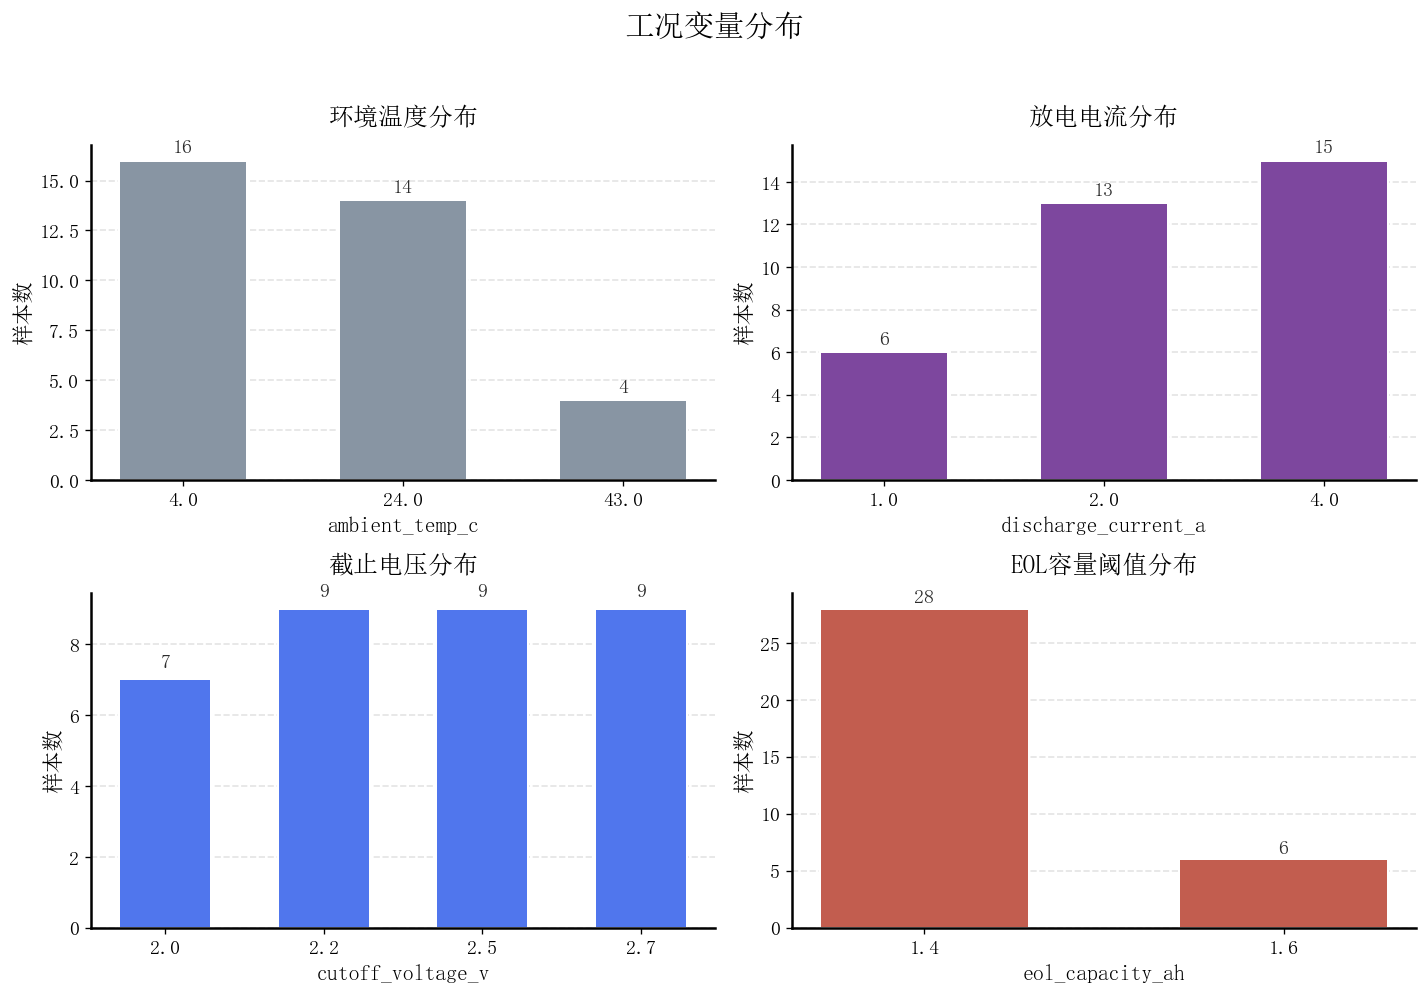

已保存加深版分布图: C:\\Users\\PLUTO\\Desktop\\battery-rul\results\eda\chapter3_3_1_condition_distribution_enhanced_20260327_091353.png


In [4]:
# 3.3.1 图表美化：加深配色 + 增大字体以符合论文打印与答辩展示要求
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=120)

# 在你原先偏好的配色方案基础上，降低了明度、提高了饱和度，解决“颜色太淡”的问题
paper_palette_darker = ['#8895A3', '#7D479E', '#5076ED', '#C25D4F']

plots = [
    ('ambient_temp_c', '环境温度分布'),
    ('discharge_current_a', '放电电流分布'),
    ('cutoff_voltage_v', '截止电压分布'),
    ('eol_capacity_ah', 'EOL容量阈值分布'),
]

for i, (ax, (col, title)) in enumerate(zip(axes.flatten(), plots)):
    vc = df_eda[col].value_counts().sort_index()
    x = np.arange(len(vc))
    y = vc.values
    labels = vc.index.astype(str).tolist()

    bars = ax.bar(
        x, y,
        width=0.58,
        color=paper_palette_darker[i],
        edgecolor='white',
        linewidth=1.2,
        alpha=1.0, # 移除原先的透明度，使颜色更加厚实
    )

    # 全面放大字体，同时给标题加粗
    ax.set_title(title, fontsize=15, pad=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=13)
    ax.set_ylabel('样本数', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    
    # 网格线稍微加深，并将边框线加粗，以免显得单薄
    ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=1.0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)

    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + 0.25,
            f'{int(h)}',
            ha='center',
            va='bottom',
            fontsize=12,          # 柱子上方的数据标签字号从 8 调到 12
            fontweight='bold',    # 加粗
            color='#2C2C2C'       # 颜色改为深灰黑
        )

fig.suptitle('工况变量分布', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()

ts_fig = datetime.now().strftime('%Y%m%d_%H%M%S')
fig_path = os.path.join(OUT_DIR, f'chapter3_3_1_condition_distribution_enhanced_{ts_fig}.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('已保存加深版分布图:', fig_path)

In [5]:
n_total = len(df_eda)
temp_levels = sorted(df_eda['ambient_temp_c'].unique().tolist())
current_levels = sorted(df_eda['discharge_current_a'].unique().tolist())
cutoff_levels = sorted(df_eda['cutoff_voltage_v'].unique().tolist())
eol_levels = sorted(df_eda['eol_capacity_ah'].unique().tolist())
anomaly_n = int((df_eda['anomaly_flag'] > 0).sum())

text = (
    f'基于 processed 目录中可用样本，本文共纳入 {n_total} 节电池用于后续建模分析。'
    f'在工况构成上，环境温度覆盖 {temp_levels} ℃，放电电流覆盖 {current_levels} A，'
    f'截止电压覆盖 {cutoff_levels} V，EOL 容量阈值包含 {eol_levels} Ah。'
    f'其中 anomaly_flag=1 的样本数为 {anomaly_n}，主要对应低温异常风险组。'
)

print('=== 3.3.1 可直接引用文本草稿 ===')
print(text)

txt_path = os.path.join(OUT_DIR, f'chapter3_3_1_paragraph_{ts}.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(text + '\n')
print('已保存文本草稿:', txt_path)

=== 3.3.1 可直接引用文本草稿 ===
基于 processed 目录中可用样本，本文共纳入 34 节电池用于后续建模分析。在工况构成上，环境温度覆盖 [4.0, 24.0, 43.0] ℃，放电电流覆盖 [1.0, 2.0, 4.0] A，截止电压覆盖 [2.0, 2.2, 2.5, 2.7] V，EOL 容量阈值包含 [1.4, 1.6] Ah。其中 anomaly_flag=1 的样本数为 16，主要对应低温异常风险组。
已保存文本草稿: C:\\Users\\PLUTO\\Desktop\\battery-rul\results\eda\chapter3_3_1_paragraph_20260327_091353.txt


## 3.3.2 容量衰减归积分析（Capacity Degradation Accumulation）

本节在 02 笔记本已有工作的基础上，统一比较不同工况下容量衰减轨迹，并构建“累计衰减量”指标：

- 容量轨迹：$C_k$ 随循环次数 $k$ 的变化；
- 累计衰减量：$\Delta C_k = C_1 - C_k$；
- 累计衰减率：$\Delta C_k^{(\%)} = \frac{C_1 - C_k}{C_1} \times 100\%$。

通过该分析可定量比较不同工况下的退化速度、总衰减幅度与局部容量恢复现象。

In [6]:
import scipy.io

def get_capacity_robust(file_path):
    mat_data = scipy.io.loadmat(file_path)
    battery_name = [k for k in mat_data.keys() if not k.startswith('__')][0]
    cycles = mat_data[battery_name][0, 0]['cycle'][0]

    capacities = []
    for i in range(len(cycles)):
        if cycles[i]['type'][0] == 'discharge':
            try:
                cap = float(cycles[i]['data'][0, 0]['Capacity'][0, 0])
                if np.isfinite(cap):
                    capacities.append(cap)
            except (IndexError, ValueError, TypeError):
                continue
    return battery_name, np.array(capacities, dtype=float)

battery_configs = [
    (r'1. BatteryAgingARC-FY08Q4/B0005.mat', '室温恒流2A'),
    (r'2. BatteryAgingARC_25_26_27_28_P1/B0025.mat', '室温方波4A'),
    (r'3. BatteryAgingARC_25-44/B0038.mat', '多温多电流'),
    (r'4. BatteryAgingARC_45_46_47_48/B0045.mat', '4℃固定1A'),
    (r'5. BatteryAgingARC_49_50_51_52/B0049.mat', '4℃固定2A(中断)'),
    (r'6. BatteryAgingARC_53_54_55_56/B0053.mat', '4℃固定2A(EOL)'),
]

RAW_ROOT = os.path.join(PROJECT_ROOT, 'data', 'raw')
curve_records = []
summary_rows = []

for rel_path, group_name in battery_configs:
    abs_path = os.path.join(RAW_ROOT, rel_path)
    if not os.path.exists(abs_path):
        print(f'[跳过] 文件不存在: {abs_path}')
        continue

    battery_name, caps = get_capacity_robust(abs_path)
    if len(caps) < 5:
        print(f'[跳过] {battery_name} 有效放电循环过少: {len(caps)}')
        continue

    cycles = np.arange(1, len(caps) + 1)
    init_cap = float(caps[0])
    cum_loss_ah = init_cap - caps
    cum_loss_pct = np.where(init_cap > 0, cum_loss_ah / init_cap * 100.0, np.nan)

    diffs = np.diff(caps)
    regen_steps = int(np.sum(diffs > 0))
    max_regen_mah = float(np.max(np.maximum(diffs, 0.0)) * 1000.0) if len(diffs) > 0 else 0.0

    total_fade_ah = float(caps[0] - caps[-1])
    total_fade_pct = float(total_fade_ah / caps[0] * 100.0) if caps[0] > 0 else np.nan
    avg_fade_mah_per_cycle = float(total_fade_ah / (len(caps) - 1) * 1000.0) if len(caps) > 1 else np.nan

    for c, cap, d_ah, d_pct in zip(cycles, caps, cum_loss_ah, cum_loss_pct):
        curve_records.append({
            'battery_id': battery_name,
            'group': group_name,
            'cycle': int(c),
            'capacity_ah': float(cap),
            'cum_loss_ah': float(d_ah),
            'cum_loss_pct': float(d_pct),
        })

    summary_rows.append({
        'battery_id': battery_name,
        'group': group_name,
        'num_cycles': int(len(caps)),
        'init_capacity_ah': float(caps[0]),
        'end_capacity_ah': float(caps[-1]),
        'total_fade_ah': total_fade_ah,
        'total_fade_pct': total_fade_pct,
        'avg_fade_mah_per_cycle': avg_fade_mah_per_cycle,
        'regen_steps': regen_steps,
        'max_regen_mah': max_regen_mah,
    })

df_curve = pd.DataFrame(curve_records)
df_deg_summary = pd.DataFrame(summary_rows).sort_values('total_fade_pct', ascending=False).reset_index(drop=True)

print('累计曲线记录数:', len(df_curve))
print('纳入归积分析电池数:', len(df_deg_summary))
display(df_deg_summary)

累计曲线记录数: 396
纳入归积分析电池数: 6


,battery_id,group,num_cycles,init_capacity_ah,end_capacity_ah,total_fade_ah,total_fade_pct,avg_fade_mah_per_cycle,regen_steps,max_regen_mah
0,B0053,4℃固定2A(EOL),56,1.069142,0.000000,1.069142,100.000000,19.438942,27,127.223402
1,B0045,4℃固定1A,72,1.081979,0.606948,0.475032,43.903958,6.690588,24,730.852559
2,B0005,室温恒流2A,168,1.856487,1.325079,0.531408,28.624384,3.182084,36,88.332905
3,B0049,4℃固定2A(中断),25,0.858373,0.691389,0.166984,19.453577,6.957675,7,1014.269482
4,B0025,室温方波4A,28,1.847011,1.767789,0.079222,4.289204,2.934151,8,22.314611
5,B0038,多温多电流,47,0.898057,1.530148,-0.632090,-70.384165,-13.741091,19,733.408413


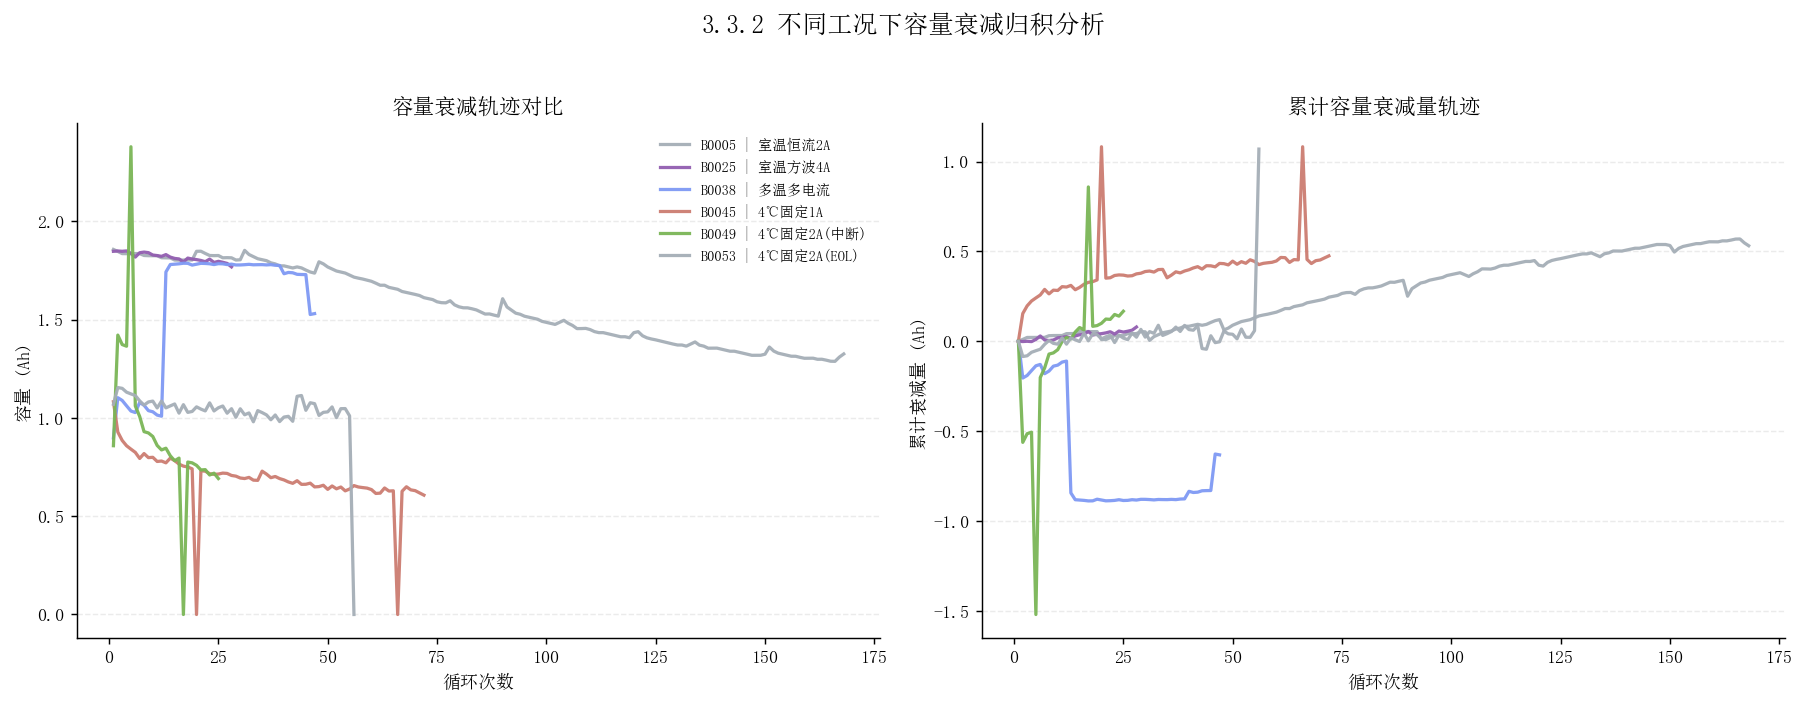

已保存图: C:\\Users\\PLUTO\\Desktop\\battery-rul\results\eda\chapter3_3_2_degradation_accumulation_20260327_091355.png
已保存表: C:\\Users\\PLUTO\\Desktop\\battery-rul\results\eda\chapter3_3_2_degradation_summary_20260327_091355.csv
已保存曲线数据: C:\\Users\\PLUTO\\Desktop\\battery-rul\results\eda\chapter3_3_2_degradation_curve_20260327_091355.csv


In [7]:
if df_curve.empty:
    print('df_curve 为空，请先运行上一单元。')
else:
    plot_palette = ['#A5AEB7', '#925EB0', '#7E99F4', '#CC7C71', '#7AB656']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), dpi=130)

    # 左图：容量衰减轨迹
    for i, (bid, part) in enumerate(df_curve.groupby('battery_id')):
        color = plot_palette[i % len(plot_palette)]
        axes[0].plot(
            part['cycle'].values,
            part['capacity_ah'].values,
            color=color, linewidth=1.8, alpha=0.95,
            label=f"{bid} | {part['group'].iloc[0]}"
        )
    axes[0].set_title('容量衰减轨迹对比')
    axes[0].set_xlabel('循环次数')
    axes[0].set_ylabel('容量 (Ah)')
    axes[0].grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.8)
    axes[0].legend(fontsize=8, frameon=False)

    # 右图：累计衰减量轨迹
    for i, (bid, part) in enumerate(df_curve.groupby('battery_id')):
        color = plot_palette[i % len(plot_palette)]
        axes[1].plot(
            part['cycle'].values,
            part['cum_loss_ah'].values,
            color=color, linewidth=1.8, alpha=0.95,
            label=f"{bid}"
        )
    axes[1].set_title('累计容量衰减量轨迹')
    axes[1].set_xlabel('循环次数')
    axes[1].set_ylabel('累计衰减量 (Ah)')
    axes[1].grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.8)

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('3.3.2 不同工况下容量衰减归积分析', fontsize=14, y=1.03)
    plt.tight_layout()

    ts_deg = datetime.now().strftime('%Y%m%d_%H%M%S')
    fig_deg_path = os.path.join(OUT_DIR, f'chapter3_3_2_degradation_accumulation_{ts_deg}.png')
    plt.savefig(fig_deg_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print('已保存图:', fig_deg_path)

    summary_path = os.path.join(OUT_DIR, f'chapter3_3_2_degradation_summary_{ts_deg}.csv')
    curve_path = os.path.join(OUT_DIR, f'chapter3_3_2_degradation_curve_{ts_deg}.csv')
    df_deg_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')
    df_curve.to_csv(curve_path, index=False, encoding='utf-8-sig')
    print('已保存表:', summary_path)
    print('已保存曲线数据:', curve_path)

### 3.3.2 小结（可用于论文正文）

从容量衰减归积结果可以看出，不同工况下电池在总衰减幅度、单位循环衰减速率以及局部容量恢复频次上存在明显差异。
这说明后续建模不能仅依赖统一退化假设，而应将工况差异显式纳入特征表达与训练评估协议，以提升跨场景泛化能力。

## 下一步（3.3.3）

建议继续补充：关键特征相关性与工况差异耦合分析（容量-放电时间-最高温度），用于衔接后续预处理策略与模型输入设计。